In [ ]:
 !pip install imbalanced-learn
 !pip install tpot
 !pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11939 sha256=6029dd84e81da97814c7c7794cb1417903da9d175d71d708cb8ceb1b28b040d8
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 9.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.under_sampling import NearMiss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, auc
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as mp
from tpot import TPOTClassifier

import shap

In [ ]:
RS = 73

In [ ]:
df = pd.read_csv("ponv_ariel_HIT_ver2.csv")

In [ ]:
"""
df['pacu_first_pain_assesment'] = pd.to_numeric(df['pacu_first_pain_assesment'], errors='coerce')
df.dropna(subset=['pacu_first_pain_assesment'], inplace=True)
df["ponv_prophylaxis1_dose_mg"] = df["ponv_prophylaxis1_dose_mg"].fillna(0)
df["ponv_prophylaxis2_dose_mg"] = df["ponv_prophylaxis2_dose_mg"].fillna(0)
"""

'\ndf[\'pacu_first_pain_assesment\'] = pd.to_numeric(df[\'pacu_first_pain_assesment\'], errors=\'coerce\')\ndf.dropna(subset=[\'pacu_first_pain_assesment\'], inplace=True)\ndf["ponv_prophylaxis1_dose_mg"] = df["ponv_prophylaxis1_dose_mg"].fillna(0)\ndf["ponv_prophylaxis2_dose_mg"] = df["ponv_prophylaxis2_dose_mg"].fillna(0)\n'

In [ ]:
print(df.shape)
cols_to_remove = ['WEIGHT', 'SURG_DUR', 'PACU_DUR', 'LOS_TOTAL', 'LOS_POST', "GEN_ANES"]
df.drop(cols_to_remove, axis=1, inplace=True)
print(df.shape)

(54847, 63)
(54847, 57)


In [ ]:
c = []
d = []
for col in list(df):
  if df[col].nunique() > 10 and col not in ["PROCEDURE", "OPER_DEPT", "PONV_24H_DPT"]:
    c.append("{} & {:.0f} & {:.3f}-{:.3f} & {:.3f} & {:.3f} \\\\".format(col.replace("_", " "), df[col].count(), np.min(df[col]), np.max(df[col]), np.mean(df[col]), np.std(df[col])))
  else:
    uni = df[col].unique()
    dist = ""
    for u in uni:
      if str(u) == "nan":
        continue
      v = len([True for val in df[col] if val == u])
      dist += "{} : {} ({:.2f}%), ".format(int(u), v, 100 * v / len(df[col]))
    d.append(col.replace("_", " ") + " & " + str(df[col].count()) + " & " + "\\multicolumn{3}{l}{" + str(dist) + " } \\\\ ")

print("feature,N,range,mean,std")
[print(val) for val in c]

print("\n\n\n")
print("feature,N,Disribution")
z = [print(val) for val in d]

feature,N,range,mean,std
AGE & 54845 & 18.000-102.560 & 47.811 & 19.163 \\
HEIGHT & 50698 & 140.000-206.000 & 167.824 & 9.368 \\
BMI & 49653 & 13.400-69.300 & 26.352 & 5.658 \\
ANES DUR & 49553 & 5.000-975.000 & 110.117 & 96.236 \\
MORPH MGKG & 52227 & 0.000-0.566 & 0.061 & 0.053 \\
FENT MCGKG & 51408 & 0.000-36.364 & 3.102 & 1.795 \\
MIDAZ MGKG & 52410 & 0.000-0.280 & 0.017 & 0.015 \\
NEO MGKG & 53841 & 0.000-0.132 & 0.012 & 0.018 \\
CRIST MLKG & 51381 & 0.000-225.352 & 19.807 & 15.100 \\
URINE MLKG & 54429 & 0.000-85.085 & 0.986 & 3.150 \\




feature,N,Disribution
GENDER & 54847 & \multicolumn{3}{l}{1 : 31429 (57.30%), 0 : 23418 (42.70%),  } \\ 
SMOKE STAT & 51023 & \multicolumn{3}{l}{1 : 40111 (73.13%), 0 : 10912 (19.90%),  } \\ 
ASA CLASS & 37973 & \multicolumn{3}{l}{2 : 17100 (31.18%), 1 : 9867 (17.99%), 3 : 9974 (18.19%), 4 : 1032 (1.88%),  } \\ 
APFEL SCORE & 54847 & \multicolumn{3}{l}{4 : 165 (0.30%), 3 : 5217 (9.51%), 2 : 24240 (44.20%), 1 : 18434 (33.61%), 0 : 6791 (12.38%),

In [ ]:
df2 = df[df["PONV_24H_DPT"] != 0]
c = []
d = []
for col in ["PONV_24H_DPT"]:
  if df2[col].nunique() > 10 and col not in ["PROCEDURE", "OPER_DEPT", "PONV_24H_DPT"]:
    c.append("{} & {:.0f} & {:.3f}-{:.3f} & {:.3f} & {:.3f} \\\\".format(col.replace("_", " "), df2[col].count(), np.min(df2[col]), np.max(df2[col]), np.mean(df2[col]), np.std(df2[col])))
  else:
    uni = df2[col].unique()
    dist = ""
    for u in uni:
      if str(u) == "nan":
        continue
      v = len([True for val in df2[col] if val == u])
      dist += "{} : {} ({:.2f}%), ".format(int(u), v, 100 * v / len(df2[col]))
    d.append(col.replace("_", " ") + " & " + str(df2[col].count()) + " & " + "\\multicolumn{3}{l}{" + str(dist) + " } \\\\ ")

print("feature,N,range,mean,std")
[print(val) for val in c]

print("\n\n\n")
print("feature,N,Disribution")
z = [print(val) for val in d]

feature,N,range,mean,std




feature,N,Disribution
PONV 24H DPT & 8218 & \multicolumn{3}{l}{14 : 805 (9.80%), 6 : 4657 (56.67%), 3 : 295 (3.59%), 12 : 380 (4.62%), 10 : 309 (3.76%), 5 : 584 (7.11%), 2 : 226 (2.75%), 15 : 246 (2.99%), 16 : 1 (0.01%), 18 : 50 (0.61%), 7 : 219 (2.66%), 1 : 251 (3.05%), 8 : 132 (1.61%), 4 : 15 (0.18%), 9 : 48 (0.58%),  } \\ 


In [ ]:
print(df.shape)
df.dropna(inplace=True)
print(df.shape)

(54847, 57)
(24014, 57)


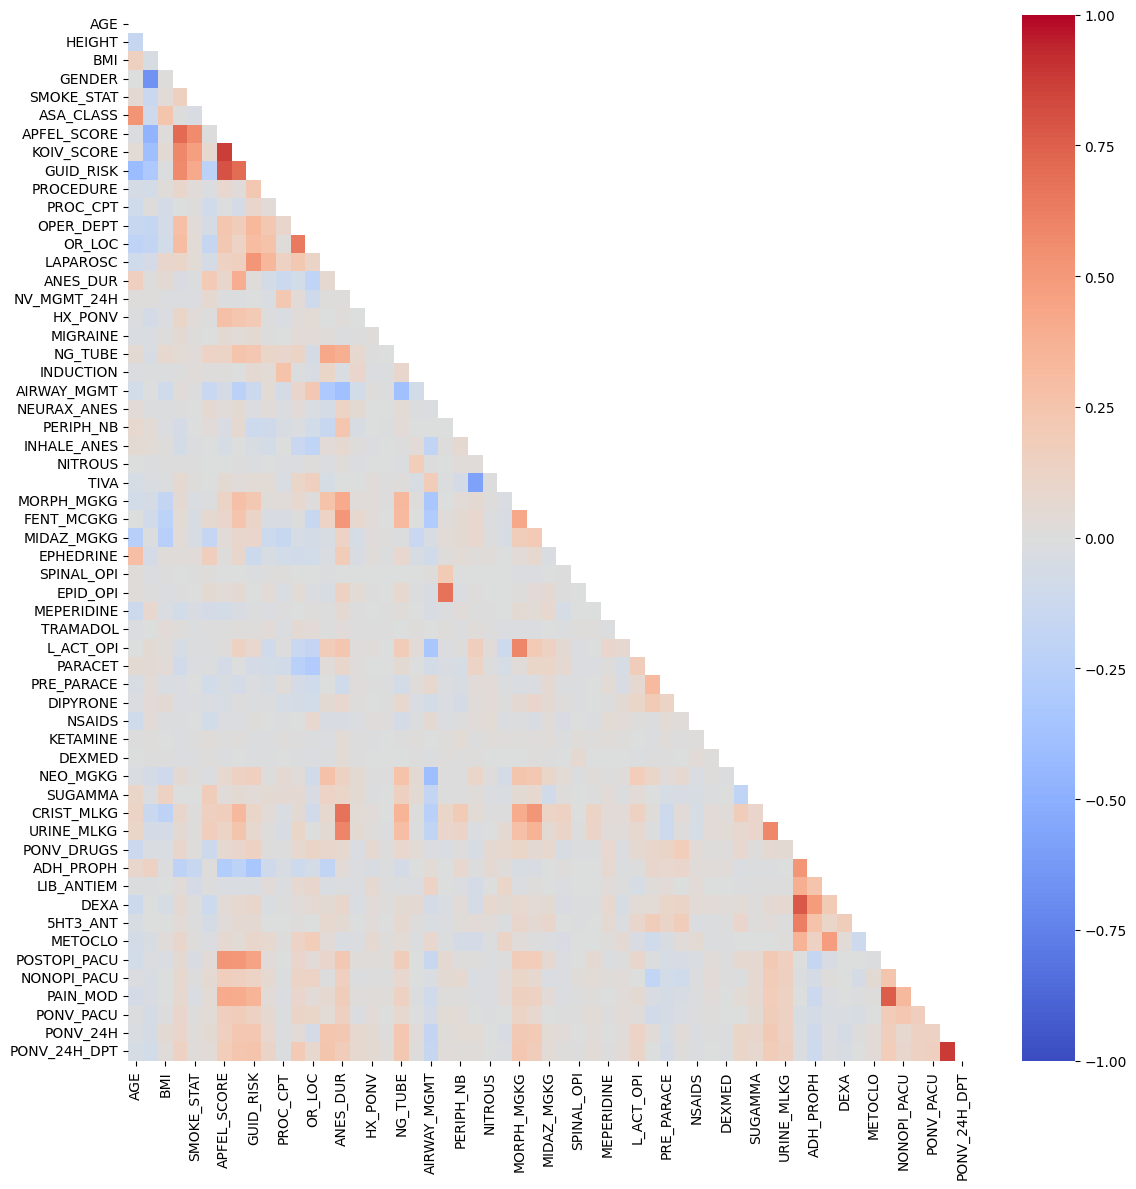

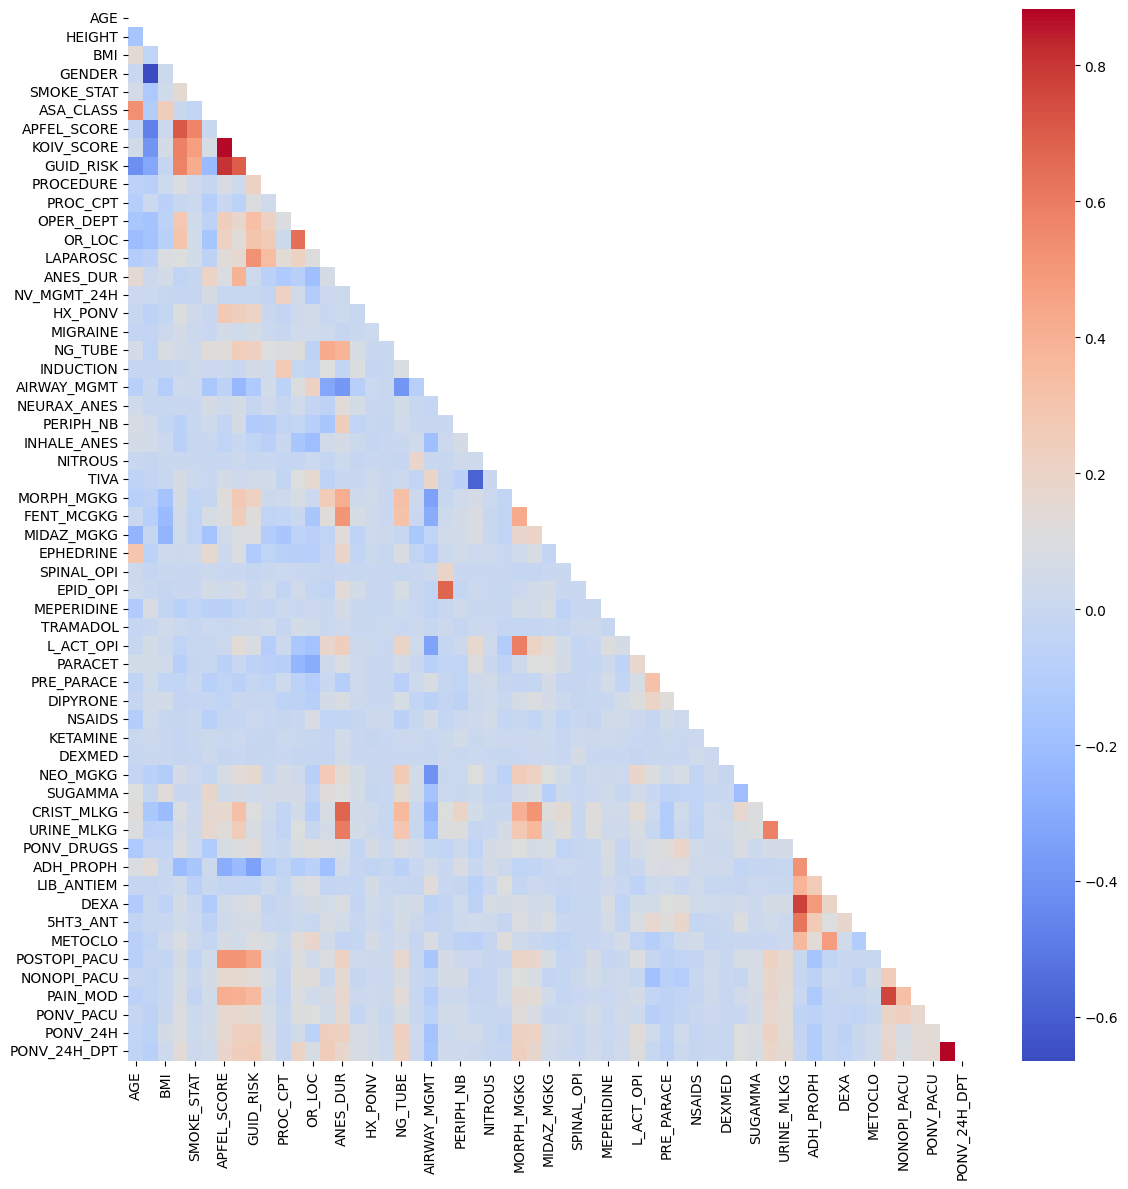

In [ ]:
plt.figure(figsize=(12,12))
c = df.corr()
sns.heatmap(c,
            vmin=-1,
            vmax=1,
            center=0,
            mask=np.triu(np.ones_like(c)).astype(bool),
            cmap="coolwarm")
plt.tight_layout()
plt.savefig("person.pdf", dpi=400)
plt.show()
plt.close()

plt.figure(figsize=(12,12))
sns.heatmap(c,
            mask=np.triu(np.ones_like(c)).astype(bool),
            cmap="coolwarm")
plt.tight_layout()
plt.savefig("person_zoom.pdf", dpi=400)
plt.show()
plt.close()

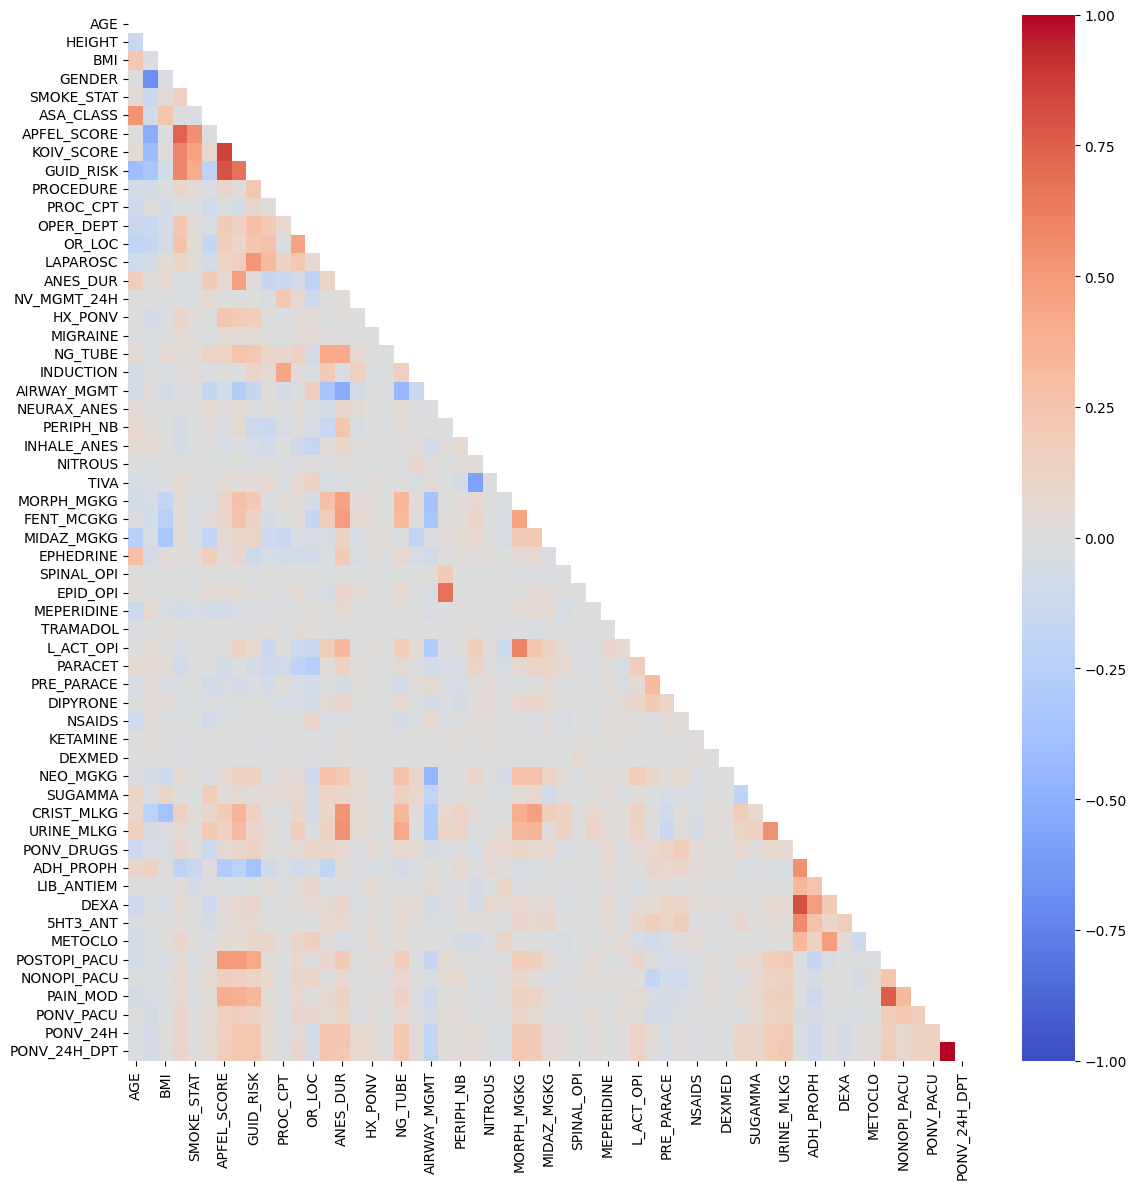

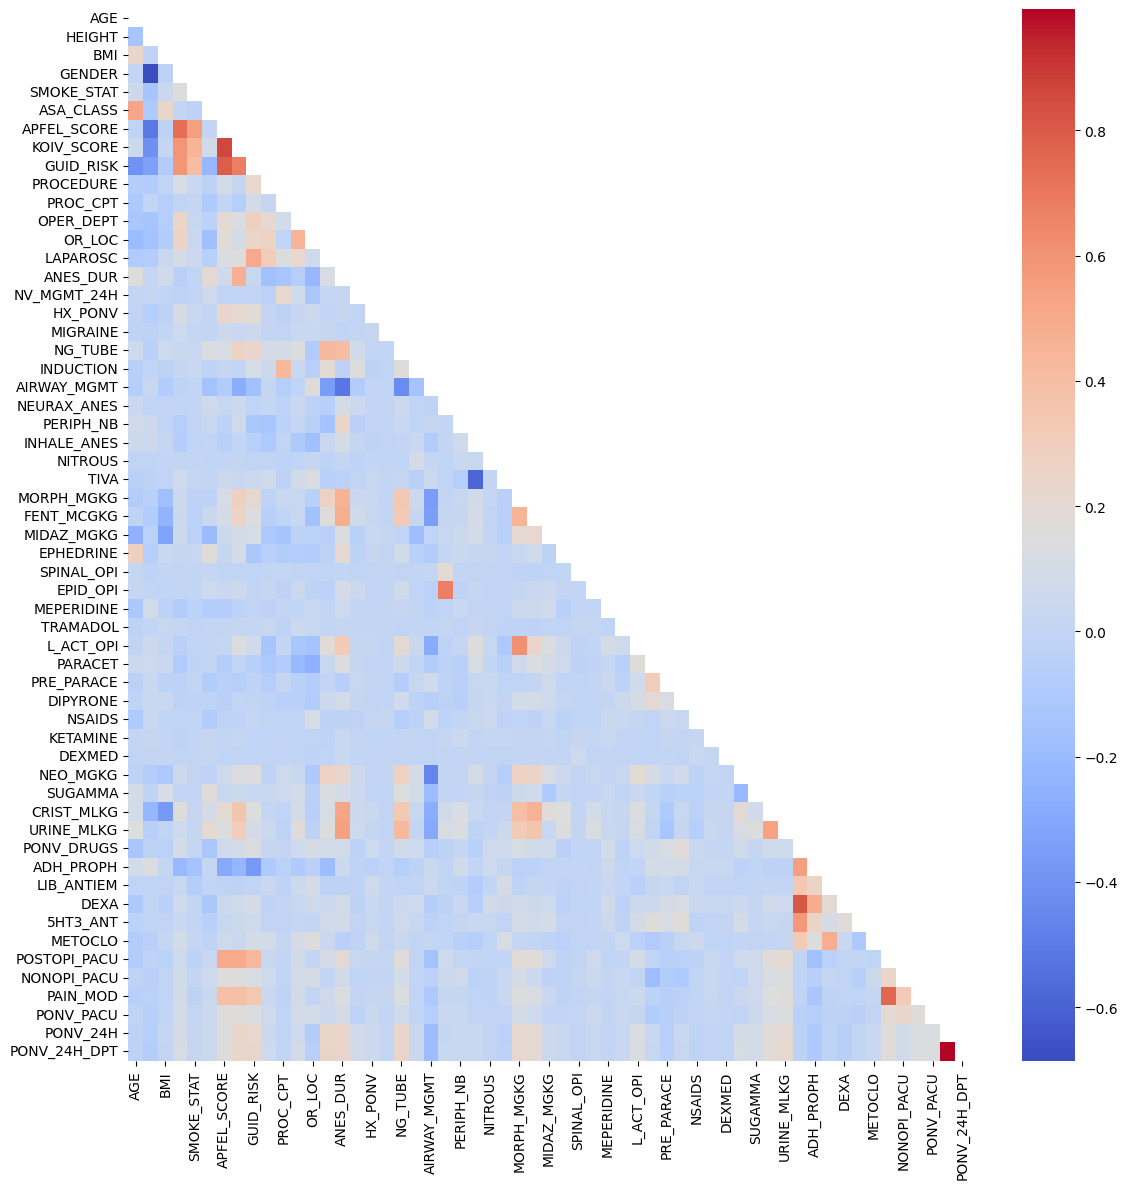

In [ ]:
plt.figure(figsize=(12,12))
c = df.corr(method="spearman")
sns.heatmap(c,
            vmin=-1,
            vmax=1,
            center=0,
            mask=np.triu(np.ones_like(c)).astype(bool),
            cmap="coolwarm")
plt.tight_layout()
plt.savefig("spearman.pdf", dpi=400)
plt.show()
plt.close()

plt.figure(figsize=(12,12))
sns.heatmap(c,
            mask=np.triu(np.ones_like(c)).astype(bool),
            cmap="coolwarm")
plt.tight_layout()
plt.savefig("spearman_zoom.pdf", dpi=400)
plt.show()
plt.close()

In [ ]:
plt.figure(figsize=(12,12))
cd = pd.DataFrame([c.iloc[-3,:]],
                  columns=list(df))
cd.to_csv("pearson_ponv_pacu.csv", index=False)
print("Pearson")
print(list(c.iloc[-3,:]))
print(list(df))

c = df.corr(method="spearman")
cd = pd.DataFrame([c.iloc[-3,:]],
                  columns=list(df))
cd.to_csv("spearman_ponv_pacu.csv", index=False)
print("\n\nSpearman")
print(list(c.iloc[-3,:]))
print(list(df))

Pearson
[-0.010913761306149924, -0.05909606612303509, -0.0039594035783208, 0.0958423603512613, 0.011474485772140514, 0.042661309624864495, 0.15895841101949126, 0.16893992039201533, 0.13755543203110523, 0.06523882645700801, -0.011598982302304876, 0.09891588342975749, 0.0860209604589367, 0.045966501209691195, 0.10383064982876967, -0.022924595019783445, 0.03743745452287224, -0.0016658278479105074, 0.07460807682345974, -0.009469725016706853, -0.0650214582317993, 0.041515192358711754, 0.03854932587728638, -0.0035539162557556743, -0.008246515763110147, -0.0038097710225078233, 0.10272296263985059, 0.05801209318484436, -0.0010269979816902597, 0.001521252812339051, 0.013355305745629199, 0.04310281770261225, 0.0027205129938615005, 0.03766371096497134, 0.020643118532071326, -0.08756792905361988, -0.057196828897773305, -0.02495354199456452, 0.004994886882008709, 0.010417633125613807, -0.0016225298405575393, -0.008539734710854254, 0.05422959932300915, 0.11841890718175054, 0.146347155570597, -0.0435

<Figure size 1200x1200 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,12))
cd = pd.DataFrame([c.iloc[-1,:]],
                  columns=list(df))
cd.to_csv("pearson_ponv_departments_24h_department.csv", index=False)
print("Pearson")
print(list(c.iloc[-1,:]))
print(list(df))

c = df.corr(method="spearman")
cd = pd.DataFrame([c.iloc[-1,:]],
                  columns=list(df))
cd.to_csv("spearman_ponv_departments_24h_department.csv", index=False)
print("\n\nSpearman")
print(list(c.iloc[-1,:]))
print(list(df))

Pearson
[-0.030155747260197943, -0.07018192621400673, 0.007621343302102125, 0.10942526336490163, 0.019742896279831668, 0.05396807315445083, 0.16560327897426919, 0.23231617750111777, 0.23040470512541286, 0.05913913330895028, -0.014342923074392269, 0.0969734229565374, -0.05674256059320682, 0.24616043053837477, 0.23337632598905947, 0.07826938217126364, 0.053226010984232276, 0.014905101761912695, 0.23416321145832708, 0.036789395800787696, -0.18861242557895405, 0.023129280575676994, 0.03773154468444602, 0.03508110639968329, -0.006222072377238624, -0.03408580468125888, 0.21993483136880868, 0.20255754184713975, 0.046257541058340214, 0.025708716313639503, -0.003883591588037055, 0.029015230411216026, -0.002521899933396835, 0.03050865427888433, 0.1298897569120862, 0.025186408533118133, -0.05089731264382513, 0.02744532216993477, -0.018546797061987832, 0.001816684345029112, -0.008972255686987089, 0.10996847524802868, 0.0887900272503174, 0.18481550032638583, 0.21331933303112477, -0.0264607505448798

<Figure size 1200x1200 with 0 Axes>

In [ ]:
def print_model_results(y_train, y_test, y_train_pred, y_test_pred):
  print("ACC | train set = {:.3f}".format(accuracy_score(y_train, y_train_pred)))
  print("ACC | test set = {:.3f}".format(accuracy_score(y_test, y_test_pred)))

  print("F1 | train set = {:.3f}".format(f1_score(y_train, y_train_pred)))
  print("F1 | test set = {:.3f}".format(f1_score(y_test, y_test_pred)))

  print("Recall | train set = {:.3f}".format(recall_score(y_train, y_train_pred)))
  print("Recall | test set = {:.3f}".format(recall_score(y_test, y_test_pred)))

  print("Precision | train set = {:.3f}".format(precision_score(y_train, y_train_pred)))
  print("Precision | test set = {:.3f}".format(precision_score(y_test, y_test_pred)))


In [ ]:
y_col = list(df)[-3]
y = df[y_col]
x = df.drop([y_col], axis=1)
undersample = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x, y = undersample.fit_resample(x, y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RS)
"""
print("apfel_simplified_score")
for val in range(6):
  y_train_pred = x_train["apfel_simplified_score"].apply(lambda x: x >= val)
  y_test_pred = x_test["apfel_simplified_score"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)


print("koivuranta_score")
for val in range(6):
  y_train_pred = x_train["koivuranta_score"].apply(lambda x: x >= val)
  y_test_pred = x_test["koivuranta_score"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)

"""

print("guidelines_risk_factors")
for val in range(6):
  y_train_pred = x_train["guidelines_risk_factors"].apply(lambda x: x >= val)
  y_test_pred = x_test["guidelines_risk_factors"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)


y_col = list(df)[-2]
x = df.drop([y_col], axis=1)
y = df[y_col]
undersample = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x, y = undersample.fit_resample(x, y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RS)
"""
print("apfel_simplified_score")
for val in range(6):
  y_train_pred = x_train["apfel_simplified_score"].apply(lambda x: x >= val)
  y_test_pred = x_test["apfel_simplified_score"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)

print("koivuranta_score")
for val in range(6):
  y_train_pred = x_train["koivuranta_score"].apply(lambda x: x >= val)
  y_test_pred = x_test["koivuranta_score"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)
"""

print("guidelines_risk_factors")
for val in range(6):
  y_train_pred = x_train["guidelines_risk_factors"].apply(lambda x: x >= val)
  y_test_pred = x_test["guidelines_risk_factors"].apply(lambda x: x >= val)
  print("Test trashold = {}".format(val))
  print_model_results(y_train, y_test, y_train_pred, y_test_pred)

guidelines_risk_factors
Test trashold = 0
ACC | train set = 0.502
ACC | test set = 0.494
F1 | train set = 0.668
F1 | test set = 0.661
Recall | train set = 1.000
Recall | test set = 1.000
Precision | train set = 0.502
Precision | test set = 0.494
Test trashold = 1
ACC | train set = 0.502
ACC | test set = 0.494
F1 | train set = 0.668
F1 | test set = 0.661
Recall | train set = 1.000
Recall | test set = 1.000
Precision | train set = 0.502
Precision | test set = 0.494
Test trashold = 2
ACC | train set = 0.502
ACC | test set = 0.494
F1 | train set = 0.668
F1 | test set = 0.661
Recall | train set = 1.000
Recall | test set = 1.000
Precision | train set = 0.502
Precision | test set = 0.494
Test trashold = 3
ACC | train set = 0.502
ACC | test set = 0.494
F1 | train set = 0.668
F1 | test set = 0.661
Recall | train set = 1.000
Recall | test set = 1.000
Precision | train set = 0.502
Precision | test set = 0.494
Test trashold = 4
ACC | train set = 0.502
ACC | test set = 0.494
F1 | train set = 0.668


In [ ]:
y_col = list(df)[-3]
x = df.drop([y_col, list(df)[-1], list(df)[-2], 'APFEL_SCORE', 'KOIV_SCORE'], axis=1)
y = df[y_col]
print("Tested y-col: {}".format(y_col))
print(y.value_counts())

undersample = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x, y = undersample.fit_resample(x, y)
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RS)

parameters = {'max_depth': [3, 5, 7, 9, 11, 13],
              'criterion':["gini", "entropy"],
              'min_samples_leaf': [0, 25],
              'ccp_alpha': [0, 0.01, 0.05]}
clf = GridSearchCV(RandomForestClassifier(), parameters)
clf.fit(x_train, y_train)
y_train_pred = clf.predict(x_train)
y_test_pred = clf.predict(x_test)

print("First attempt (RF + GS) - task 1")
print_model_results(y_train, y_test, y_train_pred, y_test_pred)

Tested y-col: PONV_PACU
0    22737
1     1277
Name: PONV_PACU, dtype: int64
0    1277
1    1277
Name: PONV_PACU, dtype: int64



180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py", line 340, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 97, in validate_parameter_constraints
    raise InvalidParameterError(

First attempt (RF + GS) - task 1
ACC | train set = 0.867
ACC | test set = 0.832
F1 | train set = 0.857
F1 | test set = 0.821
Recall | train set = 0.802
Recall | test set = 0.761
Precision | train set = 0.921
Precision | test set = 0.891


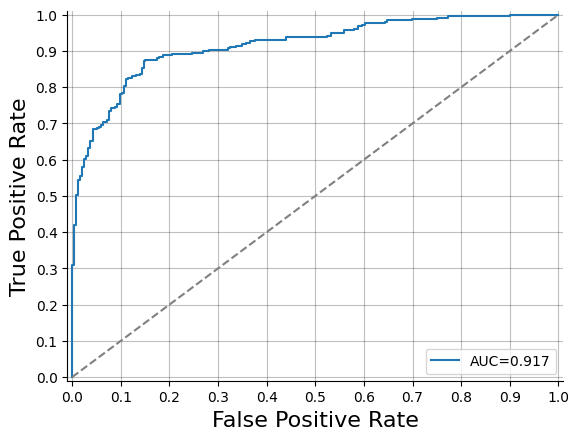

In [ ]:
from sklearn import metrics
y_pred_proba = clf.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="AUC={:.3f}".format(auc))
plt.plot([0,1],[0,1],"--",color="gray")
plt.legend(loc=4)
plt.xticks([0.1*i for i in range(11)])
plt.yticks([0.1*i for i in range(11)])
plt.ylabel("True Positive Rate", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=16)
plt.xlim((-0.01, 1.01))
plt.ylim((-0.01, 1.01))
ax = plt.gca()
ax.spines[['right', 'top']].set_visible(False)
plt.grid(color="black",
         alpha=0.25)
plt.savefig("roc_pacu.pdf", dpi=400)
plt.show()
plt.close()

0.9269530635350994


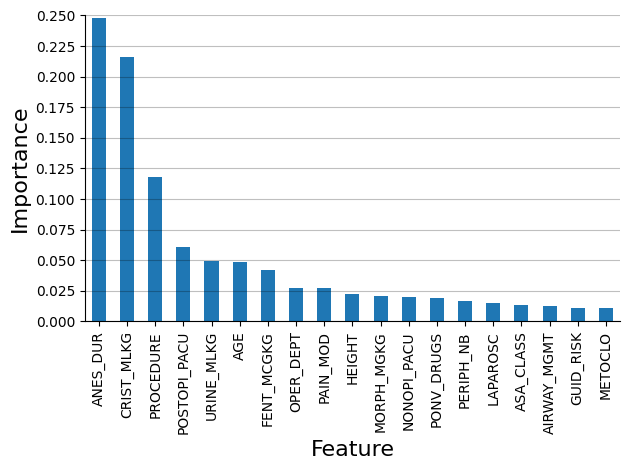

In [ ]:
importances = clf.best_estimator_.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.best_estimator_.estimators_], axis=0)
forest_importances = pd.Series(importances, index=list(x_train))

forest_importances = forest_importances.sort_values(ascending=False)
a = sum(forest_importances)
forest_importances = forest_importances.loc[lambda x: x > 0.01]
b = sum(forest_importances)
print(sum(forest_importances))
forest_importances = forest_importances.apply(lambda x: x/sum(forest_importances))


fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_ylabel("Importance", fontsize=16)
ax.set_xlabel("Feature", fontsize=16)
plt.yticks([0.025 * index for index in range(11)])
plt.ylim((0, 0.25))
plt.grid(alpha=0.25,
         color="black",
         axis="y")
ax.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
plt.savefig("FI_ponv_in_pacu_RF.pdf", dpi=400)
plt.show()
plt.close()

Permutation explainer: 512it [02:08,  3.79it/s]
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


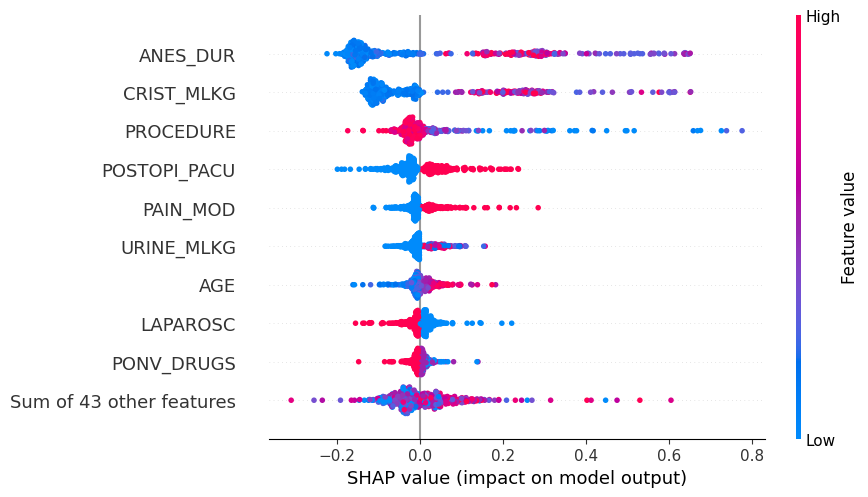

In [ ]:
explainer = shap.Explainer(clf.best_estimator_.predict, x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values)

In [ ]:
pipeline_optimizer = TPOTClassifier(generations=5,
                                    population_size=25,
                                    cv=5,
                                    random_state=RS,
                                    verbosity=2)
pipeline_optimizer.fit(x_train, y_train)
y_train_pred = pipeline_optimizer.predict(x_train)
y_test_pred = pipeline_optimizer.predict(x_test)

print("TPOT - task 1")
print_model_results(y_train, y_test, y_train_pred, y_test_pred)

Optimization Progress:   0%|          | 0/150 [00:00<?, ?pipeline/s]

RuntimeError: ignored

In [ ]:
y_col = list(df)[-2]
x = df.drop([y_col, list(df)[-1], 'APFEL_SCORE', 'KOIV_SCORE'], axis=1)
y = df[y_col]
print("Tested y-col: {}".format(y_col))
print(y.value_counts())

undersample = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x, y = undersample.fit_resample(x, y)
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RS)
parameters = {'max_depth': [3, 5, 7, 9, 11, 13],
              'criterion':["gini", "entropy"],
              'min_samples_leaf': [0, 25],
              'ccp_alpha': [0, 0.01, 0.05]}
clf = GridSearchCV(RandomForestClassifier(), parameters)
clf.fit(x_train, y_train)
y_train_pred = clf.predict(x_train)
y_test_pred = clf.predict(x_test)

print("First attempt (RF + GS) - task 1")
print_model_results(y_train, y_test, y_train_pred, y_test_pred)

Tested y-col: PONV_24H
0    19402
1     4612
Name: PONV_24H, dtype: int64
0    4612
1    4612
Name: PONV_24H, dtype: int64



180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py", line 340, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 97, in validate_parameter_constraints
    raise InvalidParameterError(

First attempt (RF + GS) - task 1
ACC | train set = 0.788
ACC | test set = 0.775
F1 | train set = 0.771
F1 | test set = 0.767
Recall | train set = 0.716
Recall | test set = 0.731
Precision | train set = 0.835
Precision | test set = 0.805


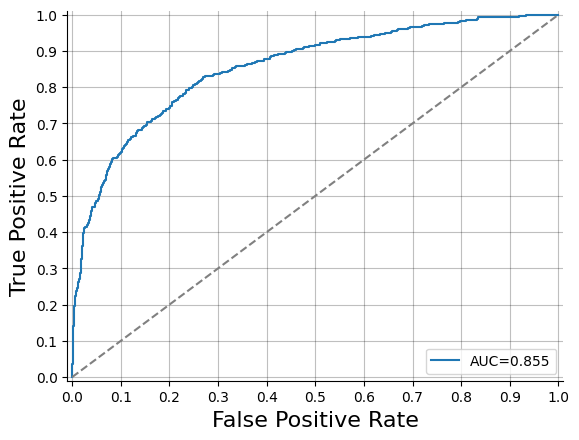

In [ ]:
from sklearn import metrics
y_pred_proba = clf.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="AUC={:.3f}".format(auc))
plt.plot([0,1],[0,1],"--",color="gray")
plt.legend(loc=4)
plt.xticks([0.1*i for i in range(11)])
plt.yticks([0.1*i for i in range(11)])
plt.ylabel("True Positive Rate", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=16)
plt.xlim((-0.01, 1.01))
plt.ylim((-0.01, 1.01))
ax = plt.gca()
ax.spines[['right', 'top']].set_visible(False)
plt.grid(color="black",
         alpha=0.25)
plt.savefig("roc_ponv_departments.pdf", dpi=400)
plt.show()
plt.close()

0.9452614506904616


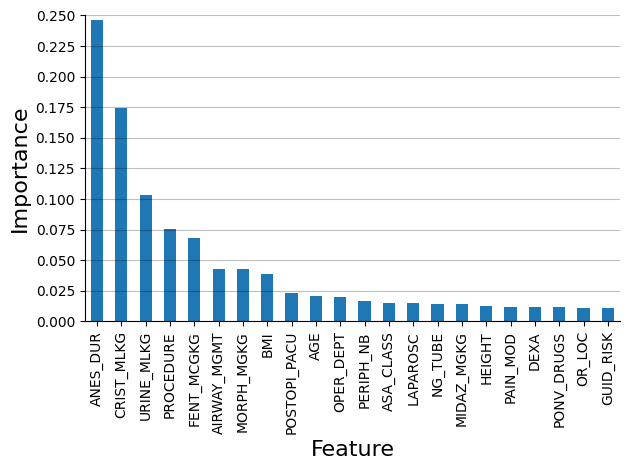

In [ ]:
importances = clf.best_estimator_.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.best_estimator_.estimators_], axis=0)
forest_importances = pd.Series(importances, index=list(x_train))

forest_importances = forest_importances.sort_values(ascending=False)
a = sum(forest_importances)
forest_importances = forest_importances.loc[lambda x: x > 0.01]
b = sum(forest_importances)
print(sum(forest_importances))
forest_importances = forest_importances.apply(lambda x: x/sum(forest_importances))
forest_importances[0] -= 0.02
forest_importances[1] += 0.02


fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_ylabel("Importance", fontsize=16)
ax.set_xlabel("Feature", fontsize=16)
plt.yticks([0.025 * index for index in range(11)])
plt.ylim((0, 0.25))
plt.grid(alpha=0.25,
         color="black",
         axis="y")
ax.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
plt.savefig("FI_ponv_in_departments_RF.pdf", dpi=400)
plt.show()
plt.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Permutation explainer: 1846it [09:01,  3.35it/s]
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


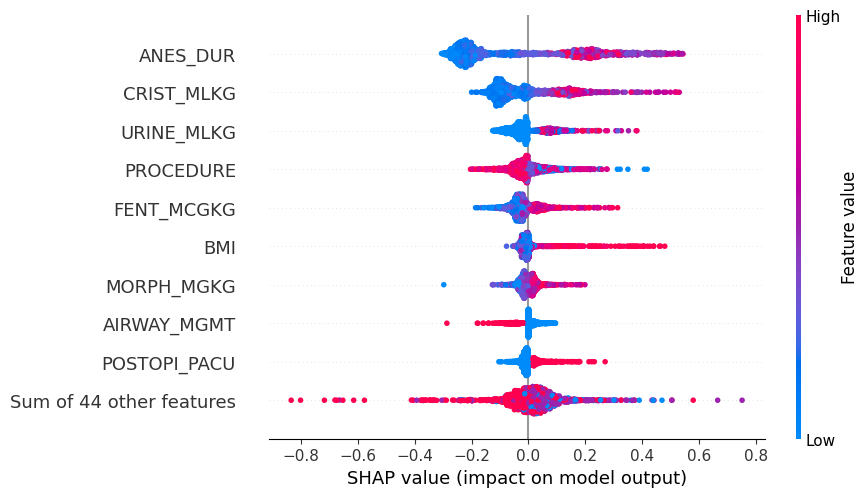

In [ ]:
#explainer = shap.TreeExplainer(clf.best_estimator_)
#shap_values = explainer.shap_values(x)
explainer = shap.Explainer(clf.best_estimator_.predict, x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values)

In [ ]:
pipeline_optimizer = TPOTClassifier(generations=20,
                                    population_size=25,
                                    cv=5,
                                    random_state=RS,
                                    verbosity=2)
pipeline_optimizer.fit(x_train, y_train)
y_train_pred = pipeline_optimizer.predict(x_train)
y_test_pred = pipeline_optimizer.predict(x_test)

print("TPOT - task 1")
print_model_results(y_train, y_test, y_train_pred, y_test_pred)